# MermaidSeqBench — Анализ результатов

Подробный разбор отчётов по каждой модели.

In [2]:
import glob, os, re, warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)

SCORE_PREFIX = 'score_'
RESULTS_DIR = '.'

# Загружаем все CSV
csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*/results__*.csv')))
models = {}
for f in csv_files:
    name = os.path.basename(os.path.dirname(f))
    models[name] = pd.read_csv(f)

print(f'Загружено моделей: {len(models)}')
for name, df in models.items():
    print(f'  {name}: {len(df)} строк')

Загружено моделей: 8
  glm-4.7-flash: 30 строк
  glm-4.7: 30 строк
  glm-5: 30 строк
  gpt-oss-120b: 30 строк
  gpt-oss-20b: 30 строк
  kimi-k2: 30 строк
  mixtral-8x22b-instruct: 30 строк
  qwen3-32b: 30 строк


In [26]:
models["qwen3-32b"]["llm_response"][4]

'```sequenceDiagram\nparticipant User\nparticipant MobileApp as Mobile App\nparticipant BFF\nparticipant AzureAD as Azure AD\nparticipant Database\n\nUser->>MobileApp: Update task\nMobileApp->>BFF: POST /Task/Update (token, task details)\nactivate BFF\n\nBFF->>AzureAD: GET /ValidateToken (token)\nactivate AzureAD\nalt Token Valid\n    AzureAD-->>BFF: Valid\n    deactivate AzureAD\n    BFF->>AzureAD: GET /GetPermissions (user ID)\n    activate AzureAD\n    alt Permissions Valid\n        AzureAD-->>BFF: Permissions granted\n        deactivate AzureAD\n        BFF->>Database: UPDATE TaskStatus\n        activate Database\n        alt Update Successful\n            Database-->>BFF: Success\n            deactivate Database\n            Note right of BFF: Notify stakeholders via notification service\n            BFF->>MobileApp: Send push notification (status, timestamp, user)\n            activate MobileApp\n            MobileApp->>BFF: Acknowledge\n            deactivate MobileApp\n        

## 1. Сводная таблица — средние скоры по критериям

In [4]:
rows = []
for name, df in models.items():
    score_cols = [c for c in df.columns if c.startswith(SCORE_PREFIX)]
    row = {'model': name}
    for col in score_cols:
        row[col.removeprefix(SCORE_PREFIX)] = df[col].mean(skipna=True)
    row['judge_avg'] = df[score_cols].mean(axis=1).mean(skipna=True)
    rows.append(row)

summary = pd.DataFrame(rows).sort_values('judge_avg', ascending=False)
summary.style.format({c: '{:.3f}' for c in summary.columns if c != 'model'}).background_gradient(
    cmap='RdYlGn', subset=[c for c in summary.columns if c != 'model'])

,model,syntax,mermaid_only,logic,completeness,activation_handling,error_and_status_tracking,judge_avg
3,gpt-oss-120b,0.984,0.982,0.912,0.915,0.903,0.879,0.929
6,mixtral-8x22b-instruct,0.960,0.977,0.877,0.862,0.840,0.800,0.886
1,glm-4.7,0.927,0.928,0.858,0.866,0.905,0.826,0.885
5,kimi-k2,0.936,0.947,0.829,0.836,0.742,0.786,0.846
0,glm-4.7-flash,0.988,0.948,0.775,0.766,0.835,0.760,0.846
7,qwen3-32b,0.874,0.900,0.781,0.803,0.803,0.761,0.821
4,gpt-oss-20b,0.807,0.590,0.516,0.591,0.811,0.647,0.660
2,glm-5,0.668,0.543,0.552,0.550,0.860,0.610,0.630


## 2. Барчарт — сравнение моделей по judge_avg

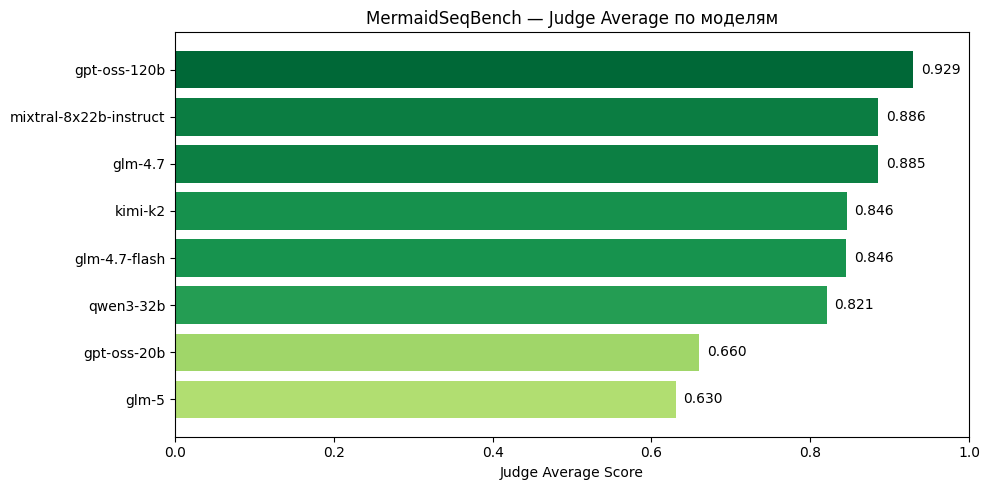

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
summary_sorted = summary.sort_values('judge_avg')
colors = plt.cm.RdYlGn(summary_sorted['judge_avg'] / summary_sorted['judge_avg'].max())
ax.barh(summary_sorted['model'], summary_sorted['judge_avg'], color=colors)
ax.set_xlabel('Judge Average Score')
ax.set_title('MermaidSeqBench — Judge Average по моделям')
ax.set_xlim(0, 1)
for i, v in enumerate(summary_sorted['judge_avg']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## 3. Радарная диаграмма — профиль каждой модели по критериям

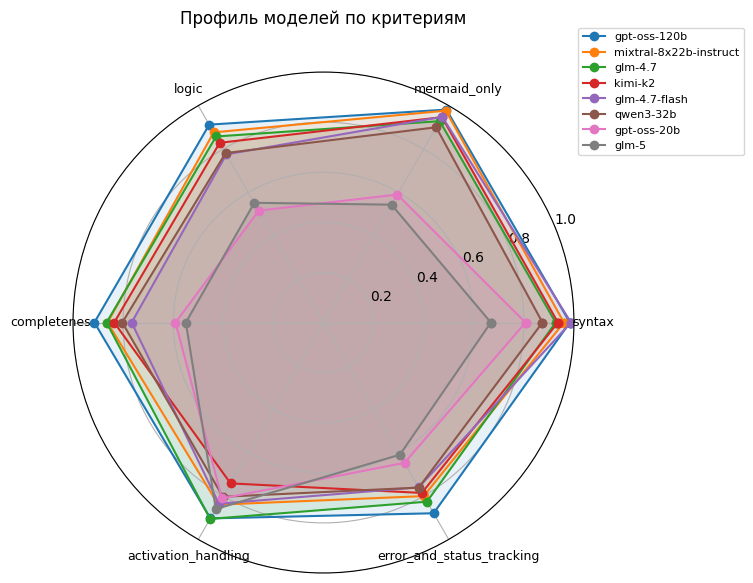

In [7]:
criteria = [c for c in summary.columns if c not in ('model', 'judge_avg')]
n_criteria = len(criteria)
angles = np.linspace(0, 2 * np.pi, n_criteria, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for _, row in summary.iterrows():
    values = [row[c] for c in criteria]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=row['model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, size=9)
ax.set_ylim(0, 1)
ax.set_title('Профиль моделей по критериям', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

## 4. Распределение скоров по каждой модели (boxplot)

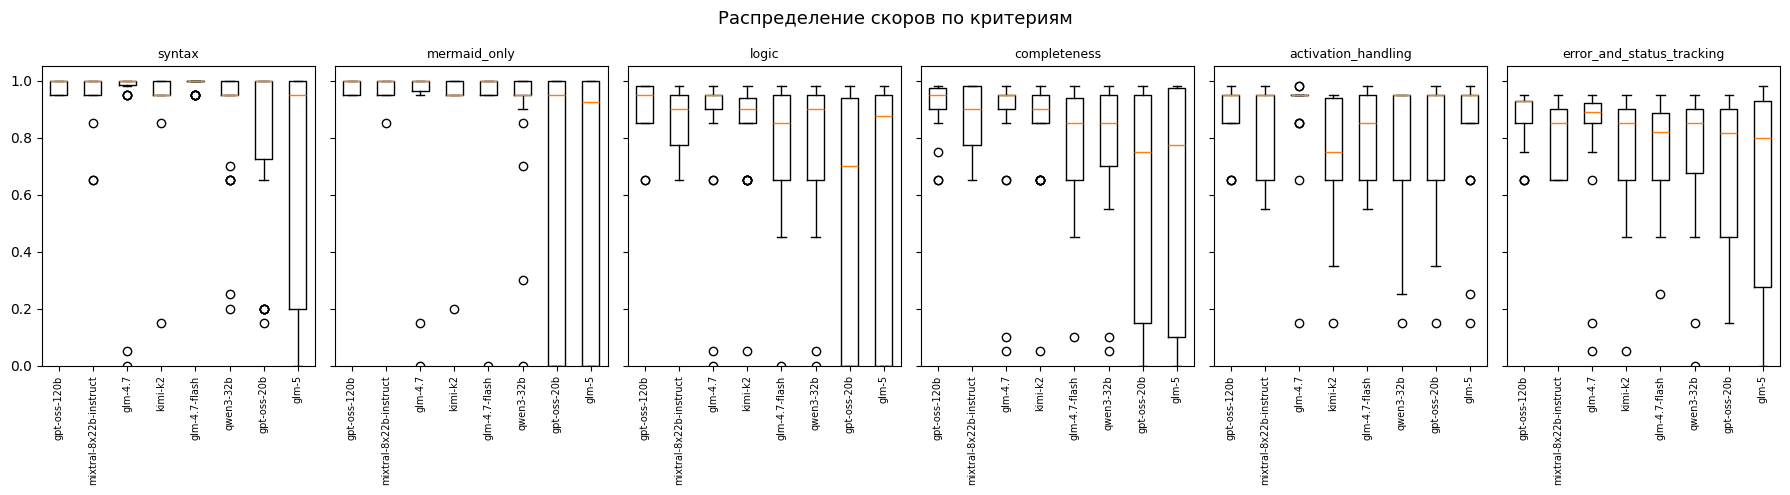

In [8]:
fig, axes = plt.subplots(1, len(criteria), figsize=(3 * len(criteria), 5), sharey=True)
model_names = summary['model'].tolist()

for i, crit in enumerate(criteria):
    col = SCORE_PREFIX + crit
    data = [models[m][col].dropna().values for m in model_names if col in models[m].columns]
    axes[i].boxplot(data, labels=model_names, vert=True)
    axes[i].set_title(crit, fontsize=9)
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)
    axes[i].set_ylim(0, 1.05)

fig.suptitle('Распределение скоров по критериям', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Детальный просмотр по модели

Выбери модель и смотри каждый ответ + оценки.

In [9]:
# Поменяй имя модели здесь:
MODEL = 'mixtral-8x22b-instruct'

df = models[MODEL]
score_cols = [c for c in df.columns if c.startswith(SCORE_PREFIX)]

print(f'Модель: {MODEL}')
print(f'Строк: {len(df)}')
print(f'\nСредние скоры:')
for col in score_cols:
    print(f'  {col.removeprefix(SCORE_PREFIX):30s} {df[col].mean():.3f}')
print(f'  {"judge_avg":30s} {df[score_cols].mean(axis=1).mean():.3f}')

Модель: mixtral-8x22b-instruct
Строк: 30

Средние скоры:
  syntax                         0.960
  mermaid_only                   0.977
  logic                          0.877
  completeness                   0.862
  activation_handling            0.840
  error_and_status_tracking      0.800
  judge_avg                      0.886


In [10]:
# Таблица скоров по строкам для выбранной модели
detail = df[['nl_task_title'] + score_cols].copy()
detail['avg'] = df[score_cols].mean(axis=1)
detail = detail.sort_values('avg')
detail.style.format({c: '{:.3f}' for c in score_cols + ['avg']}).background_gradient(
    cmap='RdYlGn', subset=score_cols + ['avg'])

,nl_task_title,score_syntax,score_mermaid_only,score_logic,score_completeness,score_activation_handling,score_error_and_status_tracking,avg
8,OAuth login flow for a mobile application 2/I,0.650,0.950,0.650,0.650,0.650,0.650,0.700
9,OAuth login flow for a mobile application 2/II,0.650,0.850,0.850,0.650,0.650,0.780,0.738
13,Send a notification to an end user via the Notification Server 3/IV,0.950,0.950,0.750,0.650,0.850,0.650,0.800
15,Read water meter 4/II,0.850,0.950,0.750,0.850,0.550,0.850,0.800
14,Read water meter 4/I,0.950,0.950,0.750,0.850,0.550,0.780,0.805
2,Uploading Documents with Secure Storage 0/III,0.950,0.950,0.750,0.650,0.950,0.650,0.817
12,Send a notification to an end user via the Notification Server 3/III,1.000,0.950,0.850,0.650,0.850,0.650,0.825
23,User registration and account creation process 6/II,0.950,1.000,0.850,0.850,0.650,0.650,0.825
0,Uploading Documents with Secure Storage 0/I,1.000,1.000,0.750,0.650,0.950,0.650,0.833
22,User registration and account creation process 6/I,0.950,1.000,0.850,0.850,0.650,0.750,0.842


## 6. Просмотр конкретного ответа модели

In [11]:
# Поменяй индекс строки (0..29):
ROW_IDX = 0

row = df.iloc[ROW_IDX]
print(f'=== Задание: {row["nl_task_title"]} ===')
print(f'\n--- Промпт (первые 500 символов) ---')
print(row['input_prompt'][:500])
print(f'\n--- Ответ модели ---')
print(row['llm_response'])
print(f'\n--- Ожидаемый ответ ---')
print(row['expected_output'])
print(f'\n--- Скоры ---')
for col in score_cols:
    print(f'  {col.removeprefix(SCORE_PREFIX):30s} {row[col]:.3f}')

=== Задание: Uploading Documents with Secure Storage 0/I ===

--- Промпт (первые 500 символов) ---
Generate a valid, syntactically correct MermaidJS UML
sequence diagram based on the provided structured input:

Input Format:
- Purpose: Description of the diagram
- Main Components: List of involved components
- Interactions: Sequence of interactions

General Guidelines:
- Identify interactions between the Main Components, distinguishing requests (->>) and responses (-->>). 
- Structure participants in this order: Users -> Frontend (Mobile/Web) -> Backend (BFF, Middleware, SOR, DB).
- Determine

--- Ответ модели ---
```sequenceDiagram
participant User
participant MA as Mobile App
participant BFF as Backend For Frontend
participant AAD as Azure AD
participant DB as Database
participant ABS as Azure Blob Storage

Note over User,MA: User uploads a document
User->>MA: Document (ID/Contract)
activate MA
MA->>BFF: POST /documents (Document, Session Token)
activate BFF
BFF->>AAD: Validate Sessi

## 7. Worst cases — самые низкие скоры по каждой модели

In [12]:
for name, df in models.items():
    score_cols = [c for c in df.columns if c.startswith(SCORE_PREFIX)]
    df_tmp = df.copy()
    df_tmp['avg'] = df_tmp[score_cols].mean(axis=1)
    worst = df_tmp.nsmallest(3, 'avg')
    print(f'\n=== {name} — 3 худших результата ===')
    for _, row in worst.iterrows():
        print(f'  [{row["avg"]:.3f}] {row["nl_task_title"]}')


=== glm-4.7-flash — 3 худших результата ===
  [0.333] Read water meter 4/IV
  [0.700] Fetching user profile from SOR, update profile to SOR 5/II
  [0.717] Send a notification to an end user via the Notification Server 3/II

=== glm-4.7 — 3 худших результата ===
  [0.083] Real-Time Notifications for Workflow Updates 1/III
  [0.200] Send a notification to an end user via the Notification Server 3/II
  [0.758] Send a notification to an end user via the Notification Server 3/III

=== glm-5 — 3 худших результата ===
  [0.133] Uploading Documents with Secure Storage 0/IV
  [0.150] User registration and account creation process 6/II
  [0.183] Uploading Documents with Secure Storage 0/I

=== gpt-oss-120b — 3 худших результата ===
  [0.783] Send a notification to an end user via the Notification Server 3/I
  [0.813] Send a notification to an end user via the Notification Server 3/II
  [0.833] Uploading Documents with Secure Storage 0/IV

=== gpt-oss-20b — 3 худших результата ===
  [0.108] Uplo